# Lever arm calculation for a single quantum dot in a FD-SOI device


## 1. Introduction

In this notebook, we will calculate the lever arm matrix for a single quantum dot defined in the previously introduced FD-SOI device.

The lever arm is a key parameter for understanding the interaction between the quantum dot and the surrounding environment, bridging intrinsic quantum-dot physics and the ‘knobs’ experimentalists can turn in a real life experiment.
In simple terms, it is essentially a conversion factor between the quantum-dot energy levels (the intrinsic physics of the quantum dot) and the applied voltages (the experimental inputs).

In what follows, we will

- Discuss the lever arm theory;
- Demonstrate how to use the corresponding lever arm solver in QTCAD®;
- Find the lever arm value for the plunger gate in the FD-SOI device;
- Evaluate the validity of the leverarm approximation for the FD-SOI device.

## 2. Preamble

Let us start by importing the necessary libraries, including Matplotlib to visualize our results.

In [1]:
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt

# QTCAD® constant and material imports.
from qtcad.device import constants as ct
from qtcad.device import materials as mt

# QTCAD® mesh and device imports.
from qtcad.device.mesh3d import Mesh, SubMesh
from qtcad.device import Device

# QTCAD® lever arm solver imports.
from qtcad.device.leverarm import Solver as LeverArmSolver
from qtcad.device.leverarm import SolverParams as LeverArmSolverParams

# QTCAD® Poisson and Schrödinger solver parameters import.
from qtcad.device.poisson import SolverParams as PoissonSolverParams
from qtcad.device.schrodinger import SolverParams as SchrodingerSolverParams


|  ||  |||                                                                 \\  
|  ||  |||         @@@@     @@@@@@@@      @@@@@        @       @@@@@@@      \\ 
|  ||  |||      @@@   @@@      @@      @@@    @       @@       @@    @@@     \\
|  ||  |||     @@       @@     @@     @@             @ @@      @@     @@@     \\
|  ||  |||     @@       @@     @@     @@            @    @     @@      @@     //
|  ||  |||      @@     @@      @@      @@@    @    @@@@@@@@    @@    @@@     //
|  ||  |||        @@@@@@       @@        @@@@@@   @@      @@   @@@@@@       // 
|  ||  |||             @@                                                  //   

                                 Version 2.1.3                                  
  Copyright (c) 2022-2026 Nanoacademic Technologies Inc. All rights reserved.   

      Welcome to QTCAD, the Quantum-Technology Computer-Aided Design tool.      

                        For documentation, please visit:                        
                      https:/

Then, as in the previous tutorials, we proceed by specifying the file paths for the mesh (`.msh`) and geometry (`.xao`) files, along with the output directory where the simulation results will be written.

Because the mesh was already refined in week 2 (specifically in the `week-2-3-poisson_schrodinge.ipynb` notebook), we will reuse that refined mesh in this notebook rather than generating a new one.

<div class="alert alert-block alert-info">

**Note**

- This notebook depends on outputs produced in week 2.
- Make sure week 2’s notebook (`week-2-3-poisson_schrodinge.ipynb`) has been executed successfully before running this one.

- We assume the following project structure:
  - All tutorials and scripts are stored in one main project directory.
  - The `meshes` and `output` directories are located at the root of this folder.
  - New scripts should be added to this main project directory as the course progresses.
  - This is how the directory structure should look like
    ```
    ├───figures/
    ├───layouts/
    ├───meshes/
    └───output/
    ```

- As a result, later notebooks will be able to reuse files generated in earlier weeks.
  - For instance, this notebook specifically reuses the previously generated refined mesh.

</div>

In [2]:
# Paths to mesh geometry and output files.
script_dir = Path("__file__").parent.resolve()
path_mesh_dir = script_dir / "meshes"
path_out = script_dir / "output"
# Path to the static mesh generated by QTCAD® Builder.
path_mesh = path_mesh_dir / "sqdfdsoi.msh"
# Path to the geometry file generated by QTCAD® Builder.
path_geo = path_mesh_dir / "sqdfdsoi.xao"
# Path to the refined mesh generated by QTCAD® non-linear Poisson solver.
path_refined_mesh = path_mesh_dir / "refined_sqdfdsoi.msh"

Let us also define the parameters for the boundary conditions, which will model the effect of applying different biases to the metallic gates.

In [3]:
# Gate biases.
back_gate_bias = -0.47
barrier_gate_1_bias = 0.55
plunger_gate_bias = 0.65
barrier_gate_2_bias = 0.55

## 3. Setting up the device

In this step, we import the mesh and device for the defined FD-SOI structure. Please note that these steps were covered in the previous week's materials.

### 3.1 Importing the mesh

The first step in setting up our device is to set up our device is to import (and show) the FD-SOI mesh previously refined in the ‘Poisson and Schrödinger simulation of a single quantum dot in FD-SOI’ notebook.

Loading mesh from file:
 C:\Proyecto_QTCAD\meshes\refined_sqdfdsoi.msh
Done.
3D MESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      590769              
Triangular elements           74165               
Tetrahedral elements          516604              
Total number of nodes         92594               
Boundary physical names       box_side, spacer_1_bottom, spacer_1_side, source_bottom, source_side, spacer_2_bottom, spacer_2_side, drain_bottom, drain_side, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_side, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, source, spacer_2, drain, channel, gate_oxide, 


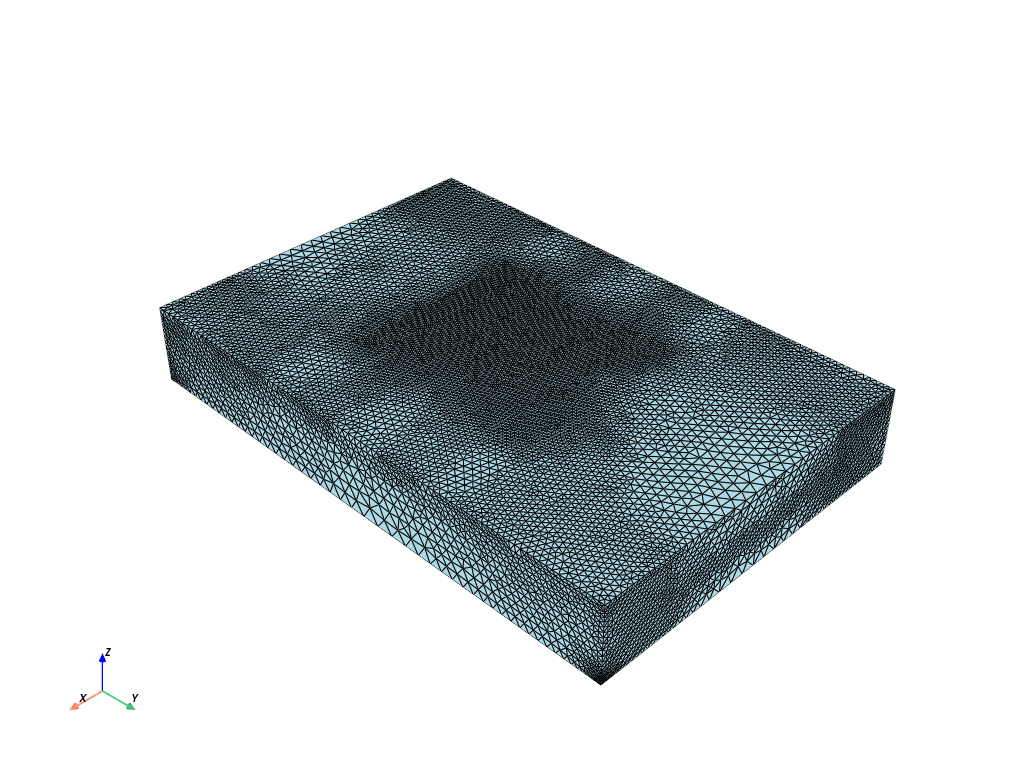

In [4]:
# Load the refined mesh.
mesh = Mesh(1e-9, path_refined_mesh)
mesh.show()

### 3.2 Creating the `Device` object

As in the previous tutorials, we continue by instantiating the `Device` object required for QTCAD® simulations. Let us also set its temperature to $0.1$ K.

In [5]:
# Instantiate device
dvc = Device(mesh, conf_carriers="e")
# Next, we set the temperature of the device to 0.1 K.
dvc.set_temperature(0.1)

### 3.3 Set up the device

Next, let us specify the material composition of each region of the device, set the boundary conditions, and define the dot region.

#### 3.3.1 Materials
We define the 3D regions and assign their material properties using the [`new_region` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_region).

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">
<dt class="sig sig-object py" id="qtcad.device.device.Device.new_region">

**new_region(tag, material, pdoping: float = 0, ndoping: float = 0, ionization_model=None, Ea=None, Ed=None, gD=None, gA=None)**

<dd><p>Create a region and add it to the device.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>tag</strong> (<em>str or int</em>) – The physical group tag (name or integer)
to associate with the physical volume in the mesh file.</p></li>
<li><p><strong>material</strong> (<em>material object</em>) – The material of which the region
consists. This attribute is optional.</p></li>
<li><p><strong>pdoping</strong> (<em>float, optional</em>) – The density of acceptors in m^-3.
Default: 0.</p></li>
<li><p><strong>ndoping</strong> (<em>float, optional</em>) – The density of donors in m^-3.
Default: 0.</p></li>
<li><p><strong>ionization_model</strong> (<em>string, optional</em>) – The ionization model used
in this Region. Default: None, which means that the default
ionization model stored in the device will be used, which
itself is “complete” by default.</p></li>
<li><p><strong>Ed</strong> (<em>float, optional</em>) – The donor binding energy. If None, does
not modify the value currently stored in the device.</p></li>
<li><p><strong>Ea</strong> (<em>float, optional</em>) – The acceptor binding energy. If None, does
not modify the value currently stored in the device.</p></li>
<li><p><strong>gD</strong> (<em>int, optional</em>) – The donor level degeneracy. If None, uses
the default value for the current material.</p></li>
<li><p><strong>gA</strong> (<em>int, optional</em>) – The acceptor level degeneracy. If None, uses
the default value for the current material.</p></li>
</ul>
</dd>
</dl>
</dd>

</div>

In [6]:
# Device device regions
dvc.new_region("box", mt.SiO2)
dvc.new_region("spacer_1", mt.SiO2)
dvc.new_region("spacer_2", mt.SiO2)
dvc.new_region("gate_oxide", mt.HfO2)
dvc.new_region("channel", mt.Si)
# Doped source region.
dvc.new_region("source", mt.Si, ndoping=1e20 * 1e6)
# Doped drain region.
dvc.new_region("drain", mt.Si, ndoping=1e20 * 1e6)

#### 3.3.2 Boundary conditions
Next, we define the boundary conditions with the [`new_gate_bnd` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.device/#qtcad.device.device.Device.new_gate_bnd).

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**new_gate_bnd(bnd_spec, phi, Ew)**

<dd><p>Create a gate boundary, i.e. an essential boundary with a primary
variable equal to the total potential due to the metal work function
and an applied potential.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>bnd_spec</strong> (<em>str | np.ndarray | list[str | np.ndarray]</em>) – Boundary specifier.</p></li>
<li><p><strong>phi</strong> (<em>float</em>) – Potential applied at the boundary.</p></li>
<li><p><strong>Ew</strong> (<em>int | float | Field | list[int | float | Field]</em>) – Metal work function.</p></li>
</ul>
</dd>
</dl>
</dd>
</div>

In [7]:
# Mid-gap work function.
Ew = mt.Si.Eg / 2 + mt.Si.chi

# Define boundary conditions.
dvc.new_gate_bnd("barrier_gate_1", barrier_gate_1_bias, Ew)
dvc.new_gate_bnd("barrier_gate_2", barrier_gate_2_bias, Ew)
dvc.new_gate_bnd("plunger_gate", plunger_gate_bias, Ew)
dvc.new_gate_bnd("back_gate", back_gate_bias, Ew)

After instantiating the device and defining its regions and boundary conditions, we can visualize the 3D geometry to verify the setup.

<div class="alert alert-block alert-info">

**Note**

When you run the next cell, a Jupyter widget will appear below it showing the device.
You can freely pan, rotate and zoom, as well as selectively show the different surfaces that make up the device.

</div>

In [8]:
dvc.show()

#### 3.3.3 Setting up the quantum-dot region with the two-corner methods

As previously covered in the ‘Poisson and Schrödinger simulation of a single quantum dot in FD-SOI’ tutorial, we use the two-corner method to define the quantum-dot region.

In [9]:
# Parameters of the dot region.
buffer_bottom = 10e-9
buffer_top = 2e-9
buffer_leads = 15e-9
buffer_spacers = 5e-9

In [10]:
# Create the dot region.
# · Channel region
channel = SubMesh(mesh, "channel")
# · Coordinates of channel corners
x0, y0, z0 = channel.glob_nodes.min(axis=0)
x1, y1, z1 = channel.glob_nodes.max(axis=0)
# · Expand by buffers.
z0 -= buffer_bottom
z1 += buffer_top
y0 += buffer_leads
y1 -= buffer_leads
x0 -= buffer_spacers
x1 += buffer_spacers

dot_region_box = [(x0, y0, z0), (x1, y1, z1)]
dvc.set_dot_region(dot_region_box)

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      183596              
Triangular elements           22108               
Tetrahedral elements          161488              
Total number of nodes         31441               
Boundary physical names       channel_bottom, channel_side, gate_oxide_bottom, 
Region physical names         channel,                      


#### 3.3.4 Setting up the `SubMesh`

In this notebook, we need to define a `SubMesh` object corresponding to the quantum-dot region. This `SubMesh` will then be used by the lever arm solver.

Previously, we showed how to instantiate a `SubMesh` using physical names that define a 3D region. However, an alternative approach is to construct a `SubMesh` object **directly** from a set of mesh nodes.

This is done using the mesh [class function `nodes_in_box` 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.mesh3d/#qtcad.device.mesh3d.Mesh.nodes_in_box). This function takes two corner points as input and returns all mesh nodes that lie inside the rectangular box defined by those corners. The returned nodes can then be passed directly to the `SubMesh` constructor to generate the `SubMesh` object.

First, we find all the mesh nodes that lie inside the quantum-dot region. To achieve this, we pass the specified corners of the quantum-dot region to `nodes_in_box`.

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**nodes_in_box(coords_min, coords_max)**

<dd><p>Gets indices of global nodes within a box.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>coords_min</strong> (<em>tuple</em>) – Minimum xyz coordinate values.</p></li>
<li><p><strong>coords_max</strong> (<em>tuple</em>) – Maximum xyz coordinate values.</p></li>
</ul>
</dd>
<dt class="field-even">Returns<span class="colon">:</span></dt>
<dd class="field-even"><p><em>1d array of int</em> – The indices of the global nodes within
the box.</p>
</dd>
</dl>
</dd>
</div>

In [11]:
# Find the mesh nodes in the dot region.
mesh_nodes = mesh.nodes_in_box(dot_region_box[0], dot_region_box[1])

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

As noted in ‘Poisson and Schrödinger simulation of a single quantum dot in FD-SOI’ notebook, the dot region also includes a buffer region around the channel, so it is important to include those nodes as well.

For this reason, we do not instantiate the `SubMesh` from physical names (as in last week’s notebook) and instead build it explicitly from nodes selected via [`nodes_in_box` method 🔗](https://docs.nanoacademic.com/qtcad/API_reference/qtcad.device.mesh3d/#qtcad.device.mesh3d.Mesh.nodes_in_box) 

</div>

3D SUBMESH STATISTICS
--------------------------------------------------------------------------------
Total number of elements      369669              
Triangular elements           35914               
Tetrahedral elements          333755              
Total number of nodes         58714               
Boundary physical names       spacer_1_bottom, spacer_2_bottom, channel_bottom, channel_side, gate_oxide_bottom, gate_oxide_top, barrier_gate_2, plunger_gate, barrier_gate_1, back_gate, 
Region physical names         box, spacer_1, spacer_2, channel, gate_oxide, 


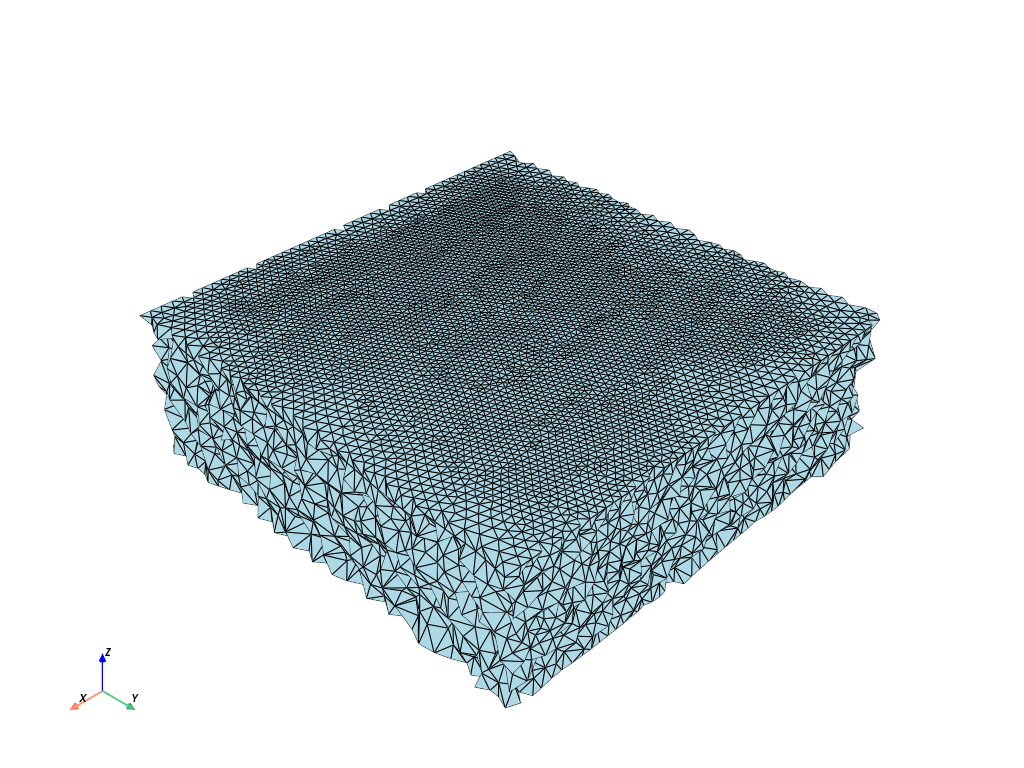

In [12]:
# Create a submesh including only the dot region.
submesh = SubMesh(mesh, mesh_nodes)
submesh.show()

<div class="alert alert-block alert-info" style="background: #F4F4F4">
    
**Question (optional)**

- Observe the edges of the submesh in figure above. Why do you think they are not perfectly smooth?
  - We encourage you to discuss your observations and hypotheses with your classmates.
  - The answer will be provided during week 3’s live session.

</div>

## 4. Lever arm simulation

In this section, we will explore the lever arm concept, define its value, and discuss its physical significance. Next, we will examine how this process is implemented in QTCAD®. Finally, we will set up the corresponding lever arm solver in QTCAD® and use it to determine the lever arm for the FD-SOI device.

### 4.1 Theory

The lever arm parameter $\alpha_{iG}$ of a gate $G$ on a quantum dot is the conversion factor between the potential $\varphi_{\text{bias},G}^0$ applied on $G$ and the $i$-th single particle eigenenergy of the quantum dot. 

More specifically, by expanding the single-particle eigenenergies $E_i$ to the **first order** in the applied bias relative to a reference bias, $\varphi_{\text{bias},G} - \varphi_{\text{bias},G}^0$, we arrive at:

$\displaystyle
E_i = E_i^0 - e \alpha_{iG} (\varphi_{\text{bias},G} - \varphi_{\text{bias},G}^0),
$

where $E_i^0$ is the eigenenergy of the $i$-th level at the reference potential $\varphi_{\text{bias},G}^0$, $e$ is the electron charge and $\alpha_{iG}$ is the lever arm of gate $G$ for the $i$-th single particle level.

Thus, we can define the lever arm parameter as

$\displaystyle
\alpha_{iG}=-\frac{1}{e}\frac{\partial E_i}{\partial \varphi_\mathrm{bias,G}}.
$

To compute the partial derivative of $E_i$ with respect to the reference potential, we approximate the lever arm parameter numerically as:

$\displaystyle
\alpha_{iG} \approx -\frac{1}{e}\frac{E_i (\varphi_{\text{bias},G}) - E_i (\varphi_{\text{bias},G}^0) }{\varphi_{\text{bias},G} - \varphi_{\text{bias},G}^0}.
$

This means that by performing two instances of Poisson and Schrödinger simulations (as covered in Week 2), we can obtain an approximate value for the lever arm, provided that the bias increment

$\displaystyle
\Delta \varphi_{G} = \varphi_{\text{bias},G} - \varphi_{\text{bias},G}^0
$ 
is sufficiently small. 

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

This is not something you can safely set to an extremely small value (e.g., $10^{-100}$) or simply to machine precision.

In practice:

- Round‑off error becomes significant if the step size is too small.

  When subtracting two nearly equal numbers, $E_i (\varphi_{\text{bias},G}) - E_i (\varphi_{\text{bias},G}^0)$, the result may be dominated by rounding error. This is called [catastrophic cancellation 🔗](https://en.wikipedia.org/wiki/Catastrophic_cancellation) in numerical analysis.

- Truncation error becomes significant if the step size is too large.

  Very large $\Delta \varphi_{G}$ means the finite difference no longer approximates the local derivative and higher‑order terms dominate.

- In finite‑element (FEM) simulations, mesh resolution and solver tolerances also introduce discretization error, so the derivative estimate can be polluted by solver noise or mesh artifacts if the perturbation is too small.

</div>

#### 4.1.1 General considerations for lever arm

According to the constant-interaction model¹, the lever arm of gate $G$ on a quantum dot can be expressed as:

$\displaystyle
\alpha_{iG} = -\frac{C_{iG}}{C_\Sigma},
$

where $C_{iG}$ is the capacitance between the dot (specifically the $i$-th single-particle state) and the gate $G$ and $C_\Sigma$ is the self capacitance of the dot.

This shows that the lever arm directly reflects the ratio of the dot–gate capacitance to the total dot capacitance. By analyzing the lever arm parameter, we can therefore gain insights into how strongly one or more gates are coupled to the quantum dot.

The lever arm is a key parameter for understanding the interaction between the quantum dot and its environment. It is essential, for example, when estimating the Rabi oscillation frequency under electric-dipole spin resonance, evaluating the impact of charge noise on spin-qubit coherence, or assessing the coupling strength between a quantum-dot system and a microwave resonator.

Moreover, when the dependence of single-particle levels on gate voltages is approximately linear, it is often possible to bypass full numerical solutions of the Poisson and Schrödinger equations during bias sweeps. This simplification, for instance when generating charge stability diagrams, can result in substantial computational savings.

---

<small>
[1] Andreas Fuhrer. Phase coherence, orbital and spin states in quantum rings. PhD thesis, ETH Zurich, 2003.
</small>

#### 4.1.2 Lever arm calculation in QTCAD®

Using QTCAD®, the lever arm parameter can be obtained by using the following workflow:

1. Poisson’s equation solution
  - Solve the nonlinear Poisson equation with a reference bias applied to gate $G$.

2. Schrödinger’s equation solution
  - Solve the single-particle Schrödinger equation to obtain the reference energy levels $E_i (\varphi_{\text{bias},G}^0)$.

3. Poisson’s equation solution with incremented bias(es)
  - Solve the nonlinear Poisson equation again with a bias slightly higher than the reference.

4. Schrödinger’s equation solution with the new bias
  - Determine the single-particle eigenenergies under the new bias $E_i (\varphi_{\text{bias},G})$.

5. Lever arm calculation
  - Using the energy levels from the above steps, the lever arm can be computed.

<div class="alert alert-block alert-info" style="background: #F4F4F4">

**Note**

QTCAD®’s lever arm solver can also take multiple bias points to examine the energy response over a wider range. This is useful for verifying whether the linear approximation (from the first-order expansion of energy levels) is valid.

In this notebook, we employ a full-range sweep method. Instead of passing two very close bias points to compute a local derivative, we provide a series of biases spanning a wider range. This allows us to:

- Check if the energy levels change linearly over the selected range.
- Fit a line to the energy versus gate bias data and extract the slope as the effective lever arm. 

If the energy response is linear in this range, the fitted slope provides a reliable lever arm and validates the linear approximation.

QTCAD® also offers a [`leverarm_matrix` solver  🔗](https://docs.nanoacademic.com/qtcad/theory_spin_fem/leverarm/#generalization-to-multiple-dot-systems-lever-arm-matrix), which supports multiple gates. This solver is intended for local lever arm calculations at a reference bias (i.e., the derivative of energy with respect to gate voltage) without performing a sweep.

</div>

### 4.2 Set up the lever arm solver 

In this step, we initialize the solver parameters for the lever arm calculation. As discussed earlier, the lever arm solver in QTCAD® internally solves both the Poisson and Schrödinger equations for the specified biases.

This means we can also configure the solver parameters for the internal Poisson and Schrödinger solvers. First, we define the parameters for these internal solvers, specifying key options as needed.

Once the Poisson and Schrödinger solver parameters are set, we pass them to the lever arm solver parameter object to complete the setup.

**Create the parameters of the non-linear Poisson solver**

In [13]:
poisson_solver_params = PoissonSolverParams()
poisson_solver_params.tol = 1e-3
poisson_solver_params.maxiter = 100

**Create the parameters of the Schrodinger solver**

In [14]:
schrodinger_solver_params = SchrodingerSolverParams()
schrodinger_solver_params.tol = 1e-6

**Create the parameters of the lever arm solver**

In [15]:
lever_arm_solver_params = LeverArmSolverParams()

# Pass the Poisson solver parameters under the attribute `pot_solver_params`
lever_arm_solver_params.pot_solver_params = poisson_solver_params
# Passing the Schrodinger solver parameters under the attribute `schrod_solver_params`
lever_arm_solver_params.schrod_solver_params = schrodinger_solver_params

Next, we select the gate for which we want to compute the lever arm. In this case, it is the `plunger_gate`, since the quantum dot forms directly beneath it.

<div class="alert alert-block alert-info" style="background: #F4F4F4">
    
**Optional exercise**

- Try computing the lever arm for other gates in the device.
- Compare the results and discuss why the values differ.

</div>

Finally, we define the range of gate biases for the lever arm calculation.

We start from the previously used reference value `plunger_gate_bias = 0.65` (from Week 2, used in the Poisson and Schrödinger simulations) and sweep up to `plunger_gate_bias = 1.15` using 5 evenly spaced points in this range. This allows us to observe the energy response over a wider bias range and determine the lever arm by fitting a line to the resulting energies.

In [16]:
# Define a range of plunger gate biases to compute the lever arm for each bias point
plunger_gate_biases = np.linspace(plunger_gate_bias, plunger_gate_bias + 0.5, 5)

### 4.3 Instantiate and run the lever arm solver

Now, let us create an instance of the lever arm solver and passing the `Device` defined above as an argument to the constructor.

We also specify:

- The label of the gate for which we want to compute the lever arm.
- The list of gate biases to investigate.
- The quantum-dot region (`dot_region`) where the solver will compute the Schrödinger equation.

As discussed earlier, the quantum-dot region is defined to cover the central channel area with a buffer. This is important because the lever arm solver only solves the Schrödinger equation within this specified region. The solver parameters configured previously are also passed to ensure consistent internal Poisson and Schrödinger solutions.

<div class="alert alert-block alert-info" style="background: #e7f2fa; width: 50%; font-size: small">

**device.leverarm.\_\_init\_\_(d, label, voltages, dot_region=None, in_path=None, out_path=None, pot_solver=None, solver_params=None, out_path_digits=3**
    
<dd><p>Constructor of the lever arm Solver class.</p>
<p>After construction of the solver object, the non-linear Poisson
and Schrödinger’s equations are solved for the specified range
of applied potentials.</p>
<dl class="field-list simple">
<dt class="field-odd">Parameters<span class="colon">:</span></dt>
<dd class="field-odd"><ul class="simple">
<li><p><strong>d</strong> (<em>device object</em>) – Device for which we want to find the lever arm
of some gate or lead.</p></li>
<li><p><strong>label</strong> (<em>string</em>) – Name of an object or list of objects for which we
want the lever arm. The object can correspond either to a
boundary (e.g., a gate or Schottky boundary) at which a
potential <span class="math notranslate nohighlight"><mjx-container class="MathJax CtxtMenu_Attached_0" jax="CHTML" style="font-size: 117.6%; position: relative;" tabindex="0" ctxtmenu_counter="2"><mjx-math class="MJX-TEX" aria-hidden="true"><mjx-msub><mjx-mi class="mjx-i"><mjx-c class="mjx-c1D711 TEX-I"></mjx-c></mjx-mi><mjx-script style="vertical-align: -0.15em;"><mjx-texatom size="s" texclass="ORD"><mjx-mi class="mjx-n"><mjx-c class="mjx-c62"></mjx-c><mjx-c class="mjx-c69"></mjx-c><mjx-c class="mjx-c61"></mjx-c><mjx-c class="mjx-c73"></mjx-c></mjx-mi></mjx-texatom></mjx-script></mjx-msub></mjx-math><mjx-assistive-mml unselectable="on" display="inline"><math xmlns="http://www.w3.org/1998/Math/MathML"><msub><mi>φ</mi><mrow data-mjx-texclass="ORD"><mi data-mjx-auto-op="false">bias</mi></mrow></msub></math></mjx-assistive-mml></mjx-container></span> is applied, or a
region in which the Fermi level is shifted by
<span class="math notranslate nohighlight"><mjx-container class="MathJax CtxtMenu_Attached_0" jax="CHTML" style="font-size: 117.6%; position: relative;" tabindex="0" ctxtmenu_counter="3"><mjx-math class="MJX-TEX" aria-hidden="true"><mjx-mo class="mjx-n"><mjx-c class="mjx-c2212"></mjx-c></mjx-mo><mjx-mi class="mjx-i"><mjx-c class="mjx-c1D452 TEX-I"></mjx-c></mjx-mi><mjx-msub><mjx-mi class="mjx-i"><mjx-c class="mjx-c1D711 TEX-I"></mjx-c></mjx-mi><mjx-script style="vertical-align: -0.15em;"><mjx-texatom size="s" texclass="ORD"><mjx-mi class="mjx-n"><mjx-c class="mjx-c62"></mjx-c><mjx-c class="mjx-c69"></mjx-c><mjx-c class="mjx-c61"></mjx-c><mjx-c class="mjx-c73"></mjx-c></mjx-mi></mjx-texatom></mjx-script></mjx-msub></mjx-math><mjx-assistive-mml unselectable="on" display="inline"><math xmlns="http://www.w3.org/1998/Math/MathML"><mo>−</mo><mi>e</mi><msub><mi>φ</mi><mrow data-mjx-texclass="ORD"><mi data-mjx-auto-op="false">bias</mi></mrow></msub></math></mjx-assistive-mml></mjx-container></span>.</p></li>
<li><p><strong>voltages</strong> (<em>1d array</em>) – Array of voltages at which the energies will
be calculated.</p></li>
<li><p><strong>dot_region</strong> (<em>string, SubMesh or list</em>) – Submesh corresponding
to the dot region, or string or list of strings
labeling region of the device (Gmsh physical groups), or list
of tuples defining two corners of a box where the dot is
defined and the Schrodinger calculation will be performed.
If None, use the entire device.
Please note that if a submesh is provided, the adaptive
feature should be disabled.</p></li>
<li><p><strong>in_path</strong> (<em>string, optional</em>) – Path to the solution to Poisson’s
equation (phi, in hdf5 format) for the first applied voltage.</p></li>
<li><p><strong>out_path</strong> (<em>string, optional</em>) – Path where solutions to Poisson’s
equation will be saved.</p></li>
<li><p><strong>pot_solver</strong> (<em>Solver object or None, optional</em>) – Solver that will
solve for the electric/confinement potential. Possible options
are the Solver objects from the
<a class="reference internal" href="../qtcad.device.poisson 2/#module-qtcad.device.poisson" title="qtcad.device.poisson"><code class="xref py py-mod docutils literal notranslate"><span class="pre">poisson</span></code></a>,
<a class="reference internal" href="../qtcad.device.schrodinger_poisson/#module-qtcad.device.schrodinger_poisson" title="qtcad.device.schrodinger_poisson"><code class="xref py py-mod docutils literal notranslate"><span class="pre">schrodinger_poisson</span></code></a>,
or <a class="reference internal" href="../qtcad.device.quantum_well 2/#module-qtcad.device.quantum_well" title="qtcad.device.quantum_well"><code class="xref py py-mod docutils literal notranslate"><span class="pre">quantum_well</span></code></a> modules.
If None, the non-linear PoissonSolver is used.</p></li>
<li><p><strong>solver_params</strong> (<em>SolverParams object, optional</em>) – Solver parameters
for lever arm solver.</p></li>
<li><p><strong>out_path_digits</strong> (<em>int, optional</em>) – Number of digits on voltage value
in output path name</p></li>
<li><p><strong>geo_file</strong> (<em>string or None, optional</em>) – path to .geo_unrolled file
containing the geometry of the problem. If geo_file is None
then Poisson’s equation is solved over the mesh saved in
<code class="docutils literal notranslate"><span class="pre">d</span></code>, and the mesh is static.
If <code class="docutils literal notranslate"><span class="pre">geo_file</span></code> is not None, adaptive meshing will be used.</p></li>
</ul>
</dd>
</dl>
</dd>
</div>

In [17]:
# Create and run the lever arm solver
print("Getting lever arm data for plunger_gate...")
lever_arm_slv = LeverArmSolver(
    d=dvc,
    label="plunger_gate",
    voltages=plunger_gate_biases,
    dot_region=submesh,
    solver_params=lever_arm_solver_params,
)

Getting lever arm data for plunger_gate...
CALCULATING LEVER ARM
Potential applied to plunger_gate: 0.65 V
--------------------------------------------------------------------------------
Solving the non-linear Poisson equation with the boundary conditions displayed below.
--------------------------------------------------------------------------------
Boundary label                              Type            Applied potential (V)
--------------------------------------------------------------------------------
barrier_gate_1                              gate            0.550000000000      
barrier_gate_2                              gate            0.550000000000      
plunger_gate                                gate            0.650000000000      
back_gate                                   gate            -0.470000000000     
--------------------------------------------------------------------------------
Poisson iter #  Max abs error  Time (s)     Max err. coords (m)              

Once the solver is instantiated, we can run it to compute the lever arm. This method performs a linear fit of the energies as a function of the applied gate biases.

In [18]:
poly_coeffs = lever_arm_slv.solve()

### 4.4 Results

After the lever arm solver finishes, we can display the computed lever arm value.

In [19]:
print(f"The lever arm is {np.abs(poly_coeffs[0])/ct.e}")

The lever arm is 0.8696082100302941


#### 4.4.1 Visualization

Next, we visualize the computed energies for all the gate biases in the specified list. These energies are stored in the lever arm solver in the attribute `energies`.

We can plot them as a function of the corresponding gate biases using a simple Matplotlib script:

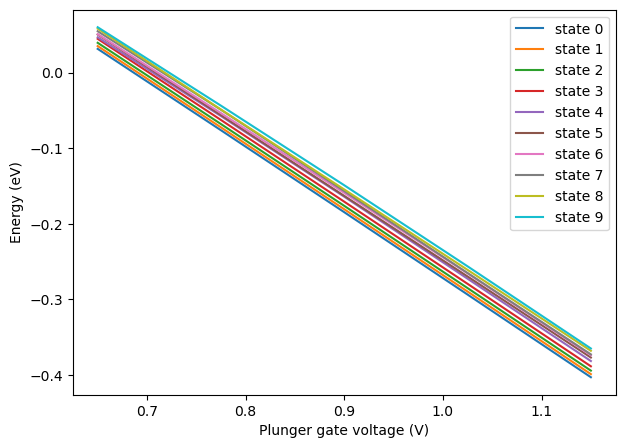

In [20]:
# Plot results.
fig, ax1 = plt.subplots()

ax1.set_ylabel("Energy (eV)")
ax1.set_xlabel("Plunger gate voltage (V)")
for i, data in enumerate(lever_arm_slv.energies.T / ct.e):
    ax1.plot(plunger_gate_biases, data, label=f"state {i}")

fig.set_size_inches(7, 5)
fig.set_dpi(100)
plt.legend()
plt.show()

As shown in the figure above, the eigenenergies of this device, up to the 9th excited state, vary nearly linearly with the plunger gate bias with their slopes determining the lever arm. This confirms that the lever arm approximation is valid within the selected bias range.

## 5. Final considerations

In this notebook, we covered the theory behind the lever arm and explored the QTCAD® lever arm solver. We used the solver to compute the lever arm for a chosen gate, visualized the energy response over a range of gate biases, and verified the validity of the lever arm approximation.

In the next notebook, we will use the lever arm computed here to speed up the simulation of Coulomb peaks in the single quantum dot FD-SOI device.